# 1、定义工具

定义网页搜索工具

In [1]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os

load_dotenv(override=True)


search_tool = TavilySearch(max_results=2,
                    tavily_api_key=os.getenv("TAVILY_API_KEY"))

# search_tool.invoke("小米最新的旗舰LLM模型是什么？")


In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI


# 加载 .env 文件
load_dotenv(override=True)

class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

# 2、绑定工具到LLM

In [3]:
llm = ChatOpenAI(
    model="mimo-v2-pro",
    api_key=os.getenv("XIAOMI_API_KEY"),
    base_url=os.getenv("XIAOMI_BASE_URL"),
)

# llm 绑定上工具
llm_with_tool = llm.bind_tools(tools=[search_tool])

In [4]:
def chatbot(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

# 3、创建一个运行工具的函数

创建一个函数来运行被调用的工具。通过将工具添加到一个名为BasicToolNode的新节点来完成，该节点检查状态中的最新消息，如果消息包含tool_calls，则调用工具

In [5]:
import json
from langchain_core.messages import ToolMessage


class BasicToolNode:
    def __init__(self, tools):
        # 传入完整的tools，注册tools_by_name这个字典
        self.tools_by_name = {tool.name:tool for tool in tools}

    def __call__(self, inputs:State):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")

        outputs = []

        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])

            outputs.append(ToolMessage(content=json.dumps(tool_result, ensure_ascii=False),
                                       name=tool_call["name"],
                                       tool_call_id=tool_call["id"]))
        return {"messages": outputs}

tool_node = BasicToolNode(tools=[search_tool])

graph_builder.add_node("tools", tool_node)

# 4、定义conditional_edges

添加了工具节点后，现在您可以定义conditional_edges。

边（Edges）将控制流从一个节点路由到下一个节点。条件边（Conditional edges）从单个节点开始，通常包含“if”语句，根据当前图状态路由到不同的节点。这些函数接收当前的图state并返回一个字符串或字符串列表，指示接下来要调用哪个（或哪些）节点。

接下来，定义一个名为route_tools的路由函数，它检查聊天机器人输出中的tool_calls。通过调用add_conditional_edges将此函数提供给图，这会告诉图，无论何时chatbot节点完成，都要检查此函数以确定下一步去哪里。

如果存在工具调用，条件将路由到tools；如果不存在，则路由到END。由于条件可以返回END，因此这次您不需要明确设置finish_point。

In [6]:
def route_tools(state: State):
    """
    在条件边（conditional_edge）中使用，如果最后一条消息包含工具调用，则路由到 ToolNode；
    否则，路由到结束节点（END）。
    :param state:
    :return:
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"在输入状态中未找到消息，无法路由到工具边（tool_edge）: {state} ")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    else:
        return END


graph_builder.add_conditional_edges(source="chatbot",
                                    path=route_tools,
                                    )
                                    # path_map={"tools": "tools", END: END})

In [7]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()

# 5、图可视化

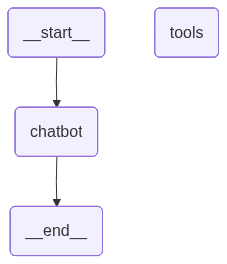

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

# 6、向机器人提问

In [10]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except BaseException as e:
        print(str(e))
        break

Assistant: 
Assistant: {"query": "新疆美食 特色美食 介绍", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.xinjiang888.com/edcontent_d.php?lang=tw&tb=4&id=601", "title": "新疆旅遊十大必吃美食 - 新疆旅遊攻略-2024，南疆北疆行程景點 | 新疆玩家俱樂部│", "content": "新疆玩家俱樂部\n\n# 新疆旅遊十大必吃美食\n\n 首頁\n 新疆旅遊攻略\n 美食攻略\n\n新疆旅遊攻略\n\n 新疆旅遊十大必吃美食\n 新疆美食推薦\n 美食天堂在新疆\n 新疆水果哪個時間最好吃?\n\n新疆美食這麼多！該吃什好呢？說到新疆美食，最令人佩服的就是新疆人利用當地獨特的地理環境和環境優勢，創造出許多種類、好吃又豐盛的特色美食。如果你到新疆一定不要錯過這十大必吃美食，保證每道菜都是鮮香可口，好吃到讓你流口水。\n\n## 一、新疆美食大盤鷄\n\n是用一整隻雞切成塊，再加上土豆塊、四川粉皮，配皮帶麵烹飪而成。加上青椒、紅椒色彩鮮艷，爽滑麻辣的雞肉和軟糯甜潤的土豆，辣中有香，令人拍案叫絕。新疆大盤雞是民族團結的產物，既有雞塊，又有相關蔬菜，還有主食。味道上有新疆人喜歡的辣味，又有令四川人著迷的麻味。  \n   \n  諮詢優惠行程▶ \n\n## 二、新疆美食手抓飯\n\n維吾爾語叫polu，以前確實是手抓著吃，不過現在是用勺。伊犁產的旱稻，加上新疆優良的胡蘿蔔洋葱和羊肉，這是一道香噴噴抓飯所必備的。出鍋的抓飯，油亮生輝，味香可口，營養豐富，是新疆人待客的上等美餐。  \n   \n  諮詢優惠行程▶ \n\n## 三、新疆頂級美食烤全羊\n\n新疆待客最高禮儀—烤全羊，它是維吾爾族的傳統美食。選用整隻羔羊宰殺後處理乾淨，用秘制調料醃製入味，再放入饢坑燜烤2小時，混合著煙火和果木香氣的烤全羊就算完成了。烤製出來的羊肉色澤金黃、皮酥肉嫩，沒有羊膻味。過去只有在重要聚會和宴席吃得到，現在已可在各巴扎上看到賣烤全羊的小攤。  \n   \n  諮詢優惠行程▶ \n\n## 四、新疆主食饢\n\n饢這個詞是波斯語，在新疆歷史悠久，是

# 7、使用预构建组件

为了方便使用，调整您的代码，将以下内容替换为LangGraph预构建组件。这些组件具有内置功能，例如并行API执行。

- BasicToolNode替换为预构建的ToolNode
- route_tools替换为预构建的tools_condition

In [5]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)

# 加载 .env 文件
load_dotenv(override=True)

search_tool = TavilySearch(max_results=2,
                    tavily_api_key=os.getenv("TAVILY_API_KEY"))

tools = [search_tool]

llm = ChatOpenAI(
    model="mimo-v2-pro",
    api_key=os.getenv("XIAOMI_API_KEY"),
    base_url=os.getenv("XIAOMI_BASE_URL"),
)

# llm 绑定上工具
llm_with_tool = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)


############### 注册工具并添加条件节点 ###############
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
######################################################

# 每次调用工具后，都会回到聊天机器人来决定下一步
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

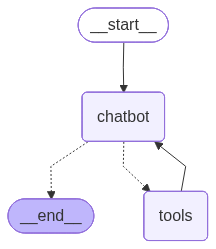

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]},
                             stream_mode="values"):
        print("Assistant:", event["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except BaseException as e:
        print(str(e))
        break

User:  nihao


Assistant: nihao
Assistant: 你好！我是小米MiMo团队开发的MiMo-v2-pro模型，很高兴为你服务！有什么我可以帮助你的吗？


User:  你好，我是nic


Assistant: 你好，我是nic
Assistant: 你好，Nic！很高兴认识你。我是小米MiMo团队开发的MiMo-v2-pro，一个拥有1万亿参数和100万token上下文窗口的AI助手。今天有什么我可以帮你探索或解答的吗？无论是日常问题还是技术话题，我都很乐意和你聊聊。
